# KAMP ⑤ 자원 최적화 AI 데이터셋 — 전체 분석 노트북

**목표:** ZIP 파일 하나를 업로드하면 자동으로 압축 해제 → 데이터 탐색/정제 → EDA → leakage-safe 시계열 feature 생성 → 모델 비교 → peak 분석 → 실패조건 분석 → 생산량 이동 what-if 분석 → 결과 저장까지 수행합니다.

### 분석 문제
- **Forecasting:** 목표 시간대의 평균 전력사용량 예측
- **Peak analysis:** 최대전력 피크가 발생하는 조건 분석
- **Failure analysis:** 예측오차가 커지는 조건 분석
- **Operational what-if:** 생산량 일부를 고위험 시간대에서 인접 저위험 시간대로 이동했을 때 예측 peak 변화 확인

### 중요: target leakage 방지
원본의 `평균`은 같은 시간대의 `15분`, `30분`, `45분`, `60분` 전력값으로 계산됩니다. 따라서 **같은 시간대의 4개 전력값을 feature로 사용하지 않습니다.**

이 노트북은 목표 시각 `t`의 전력수요를 예측할 때, **t 이전의 전력 이력 + 목표 시간대의 계획 생산량/달력 정보 + 과거 환경정보**만 사용합니다. 즉 운영 관점에서는 “다음 시간대의 계획 생산량이 이미 알려져 있다”는 설정입니다.

In [1]:
# 0. 기본 설정 — 외부 패키지 설치 없이 Colab 기본 환경에서 실행
import os, io, re, json, math, shutil, zipfile, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import joblib

warnings.filterwarnings('ignore')
np.random.seed(42)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)

OUTPUT_DIR = Path('/content/kamp05_outputs') if Path('/content').exists() else Path('./kamp05_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR = OUTPUT_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print('Output directory:', OUTPUT_DIR.resolve())

Output directory: /content/kamp05_outputs


## 1. ZIP 업로드 및 자동 압축 해제
Colab에서는 업로드 창이 뜹니다. **KAMP ⑤ 데이터 ZIP 파일 하나만 업로드**하면 됩니다.

로컬/Jupyter에서 실행할 경우 환경변수 `LOCAL_ZIP_PATH`에 ZIP 경로를 지정할 수도 있습니다.

In [2]:
# 1. ZIP 업로드 / 탐색
IN_COLAB = False
try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    pass

zip_path = None
local_zip = os.environ.get('LOCAL_ZIP_PATH', '').strip()

if local_zip and Path(local_zip).exists():
    zip_path = Path(local_zip)
    print('LOCAL_ZIP_PATH 사용:', zip_path)
elif IN_COLAB:
    print('KAMP ⑤ 자원 최적화 AI 데이터셋 ZIP 파일을 업로드하세요.')
    uploaded = files.upload()
    zip_names = [name for name in uploaded if name.lower().endswith('.zip')]
    if not zip_names:
        raise FileNotFoundError('ZIP 파일이 업로드되지 않았습니다.')
    zip_path = Path('/content') / zip_names[0]
else:
    # 현재 폴더에서 ZIP 자동 탐색
    candidates = list(Path('.').glob('*.zip')) + list(Path('/mnt/data').glob('*.zip'))
    if candidates:
        # '자원' 또는 '5.'가 들어간 파일을 우선
        candidates = sorted(candidates, key=lambda p: (('자원' not in p.name and not p.name.startswith('5.')), -p.stat().st_size))
        zip_path = candidates[0]
    else:
        raise FileNotFoundError('ZIP 파일을 찾지 못했습니다. Colab에서 업로드하거나 LOCAL_ZIP_PATH를 지정하세요.')

print('사용 ZIP:', zip_path)

EXTRACT_DIR = OUTPUT_DIR / 'extracted'
if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

csv_files = list(EXTRACT_DIR.rglob('*.csv'))
if not csv_files:
    raise FileNotFoundError('압축파일 내부에서 CSV를 찾지 못했습니다.')

# 여러 CSV가 있으면 가장 큰 CSV를 우선 사용
csv_files = sorted(csv_files, key=lambda p: p.stat().st_size, reverse=True)
csv_path = csv_files[0]
print('분석 CSV:', csv_path)
print('CSV 후보:', [str(p.relative_to(EXTRACT_DIR)) for p in csv_files])

KAMP ⑤ 자원 최적화 AI 데이터셋 ZIP 파일을 업로드하세요.


Saving 5. 자원 최적화 AI 데이터셋.zip to 5. 자원 최적화 AI 데이터셋 (1).zip
사용 ZIP: /content/5. 자원 최적화 AI 데이터셋 (1).zip
분석 CSV: /content/kamp05_outputs/extracted/5. 자원 최적화 AI 데이터셋/okm_augumented_2021.csv
CSV 후보: ['5. 자원 최적화 AI 데이터셋/okm_augumented_2021.csv']


In [3]:
# 2. CSV 로딩 — 인코딩 자동 시도
def read_csv_robust(path):
    encodings = ['utf-8-sig', 'utf-8', 'cp949', 'euc-kr']
    last_error = None
    for enc in encodings:
        try:
            df_ = pd.read_csv(path, encoding=enc)
            print(f'CSV encoding: {enc}')
            return df_
        except Exception as e:
            last_error = e
    raise last_error

df_raw = read_csv_robust(csv_path)
print('Raw shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
display(df_raw.head())

CSV encoding: utf-8-sig
Raw shape: (6168, 18)
Columns: ['날짜', '시간', '15분', '30분', '45분', '60분', '평균', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', 'day', 'd', 'm', '공장인원', '인건비']


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


## 2. 데이터 구조 검증 및 정제
실제 제공 파일 기준 핵심 컬럼은 `날짜`, `시간`, `15분`, `30분`, `45분`, `60분`, `평균`, `생산량`입니다. 컬럼명이 바뀌면 즉시 오류를 내고 현재 컬럼 목록을 보여줍니다.

In [4]:
# 3. 필수 컬럼 확인
required = ['날짜', '시간', '15분', '30분', '45분', '60분', '평균', '생산량']
missing_required = [c for c in required if c not in df_raw.columns]
if missing_required:
    raise KeyError(f'필수 컬럼이 없습니다: {missing_required}\n현재 컬럼: {df_raw.columns.tolist()}')

# 원본 보존
df = df_raw.copy()

# 날짜 파싱
s_date = df['날짜'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(8)
df['_date'] = pd.to_datetime(s_date, format='%Y%m%d', errors='coerce')
if df['_date'].isna().any():
    bad = df.loc[df['_date'].isna(), '날짜'].head().tolist()
    raise ValueError(f'날짜 파싱 실패 예시: {bad}')

# 시간 숫자화
hour_num = pd.to_numeric(df['시간'], errors='coerce')
invalid_hour = hour_num.isna() | (hour_num < 0) | (hour_num > 23)
print('Invalid hour rows:', int(invalid_hour.sum()))

# 날짜별 행 수 점검
rows_per_day = df.groupby('_date').size()
print('날짜 수:', len(rows_per_day))
print('날짜별 행 수 분포:')
print(rows_per_day.value_counts().sort_index())

# 각 날짜가 24개 행이면 잘못된 시간값을 날짜 내 순서(0~23)로 복구
within_day_order = df.groupby('_date').cumcount()
if invalid_hour.any():
    if (rows_per_day == 24).all():
        hour_num.loc[invalid_hour] = within_day_order.loc[invalid_hour]
        print(f'잘못된 시간값 {int(invalid_hour.sum())}개를 날짜 내 행순서로 복구했습니다.')
    else:
        raise ValueError('시간값 오류가 있으나 모든 날짜가 24행이 아니어서 자동 복구를 중단합니다.')

df['_hour'] = hour_num.astype(int)
df['timestamp'] = df['_date'] + pd.to_timedelta(df['_hour'], unit='h')
df = df.sort_values('timestamp').reset_index(drop=True)

# timestamp 중복/간격 점검
print('Timestamp duplicates:', int(df['timestamp'].duplicated().sum()))
print('기간:', df['timestamp'].min(), '~', df['timestamp'].max())
print('총 행 수:', len(df))

# 결측치
missing = df_raw.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print('\n결측치:')
display(missing.to_frame('missing_count'))

# 동일 시간대 평균 = 4개 15분 전력값 평균인지 검증
quarter_cols = ['15분', '30분', '45분', '60분']
quarter_mean = df[quarter_cols].mean(axis=1)
avg_diff = (quarter_mean - df['평균']).abs()
print('같은 시간대 4개 전력값 평균과 제공 평균의 최대 절대차:', float(avg_diff.max()))
print('=> 15/30/45/60분 값을 같은 시간대 평균 예측 feature로 사용하지 않습니다.')

# 기본 요약 저장
summary = {
    'rows': int(len(df)),
    'columns': int(df_raw.shape[1]),
    'start': str(df['timestamp'].min()),
    'end': str(df['timestamp'].max()),
    'invalid_hour_rows_repaired': int(invalid_hour.sum()),
    'missing_values': {str(k): int(v) for k, v in missing.to_dict().items()},
    'max_same_hour_average_difference': float(avg_diff.max())
}
with open(OUTPUT_DIR/'data_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

Invalid hour rows: 48
날짜 수: 257
날짜별 행 수 분포:
24    257
Name: count, dtype: int64
잘못된 시간값 48개를 날짜 내 행순서로 복구했습니다.
Timestamp duplicates: 0
기간: 2021-01-01 00:00:00 ~ 2021-09-14 23:00:00
총 행 수: 6168

결측치:


,missing_count
공장인원,17
풍속,3
강수량,1


같은 시간대 4개 전력값 평균과 제공 평균의 최대 절대차: 0.5
=> 15/30/45/60분 값을 같은 시간대 평균 예측 feature로 사용하지 않습니다.


## 3. Preliminary EDA
Proposal 슬라이드에 바로 사용할 수 있도록 핵심 그래프를 자동 저장합니다.

In [5]:
# 4. EDA 숫자 요약
print('평균 전력 기술통계')
display(df['평균'].describe())

corr_prod_power = df[['생산량', '평균']].corr().iloc[0, 1]
zero_prod = df['생산량'].eq(0)
peak95_full = df['평균'].quantile(0.95)

print(f'생산량-평균전력 상관계수: {corr_prod_power:.4f}')
print(f'생산량=0인 시간: {zero_prod.sum():,} / {len(df):,}')
print(f'생산량=0일 때 평균 전력: {df.loc[zero_prod, "평균"].mean():.3f}')
print(f'전체 데이터 기준 exploratory 95th percentile: {peak95_full:.3f}')

평균 전력 기술통계


,평균
count,6168.000000
mean,93.424125
std,57.355938
min,0.000000
25%,23.000000
50%,104.000000
75%,144.000000
max,208.000000


생산량-평균전력 상관계수: 0.5179
생산량=0인 시간: 2,657 / 6,168
생산량=0일 때 평균 전력: 46.189
전체 데이터 기준 exploratory 95th percentile: 177.000


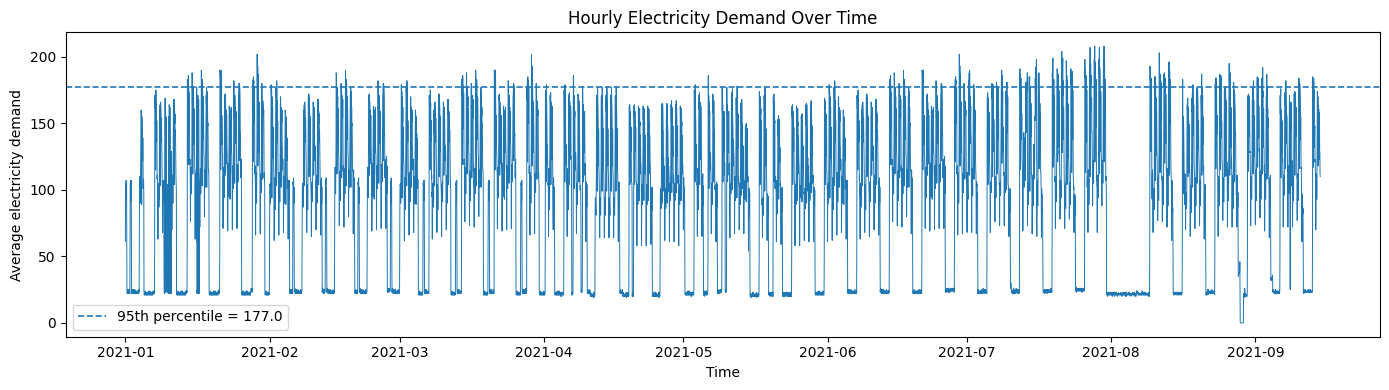

In [6]:
# 5. EDA Plot 1: 전체 시계열
plt.figure(figsize=(14, 4))
plt.plot(df['timestamp'], df['평균'], linewidth=0.7)
plt.axhline(peak95_full, linestyle='--', linewidth=1.2, label=f'95th percentile = {peak95_full:.1f}')
plt.title('Hourly Electricity Demand Over Time')
plt.xlabel('Time')
plt.ylabel('Average electricity demand')
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR/'01_power_timeseries.png', dpi=160, bbox_inches='tight')
plt.show()

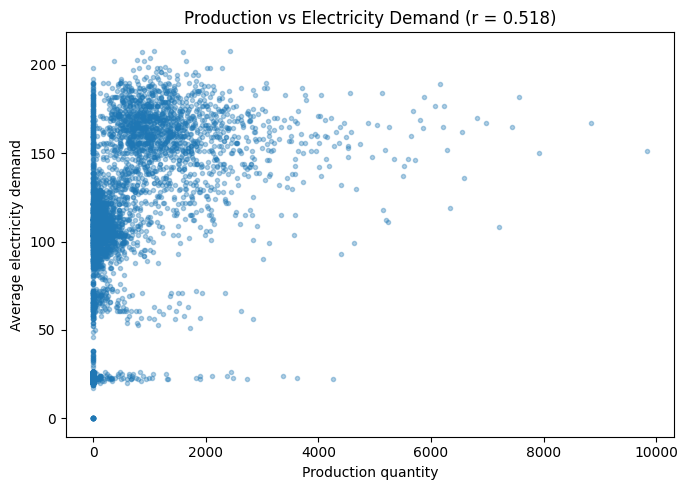

In [7]:
# 6. EDA Plot 2: 생산량 vs 전력
plt.figure(figsize=(7, 5))
plt.scatter(df['생산량'], df['평균'], s=9, alpha=0.35)
plt.title(f'Production vs Electricity Demand (r = {corr_prod_power:.3f})')
plt.xlabel('Production quantity')
plt.ylabel('Average electricity demand')
plt.tight_layout()
plt.savefig(PLOT_DIR/'02_production_vs_power.png', dpi=160, bbox_inches='tight')
plt.show()

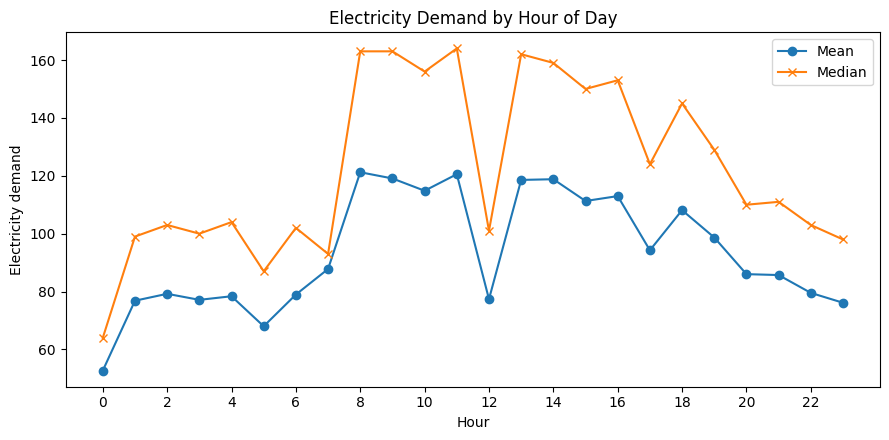

In [8]:
# 7. EDA Plot 3: 시간대별 평균 전력
hour_profile = df.groupby('_hour')['평균'].agg(['mean', 'median', 'std'])
plt.figure(figsize=(9, 4.5))
plt.plot(hour_profile.index, hour_profile['mean'], marker='o', label='Mean')
plt.plot(hour_profile.index, hour_profile['median'], marker='x', label='Median')
plt.xticks(range(0, 24, 2))
plt.title('Electricity Demand by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Electricity demand')
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR/'03_hourly_profile.png', dpi=160, bbox_inches='tight')
plt.show()

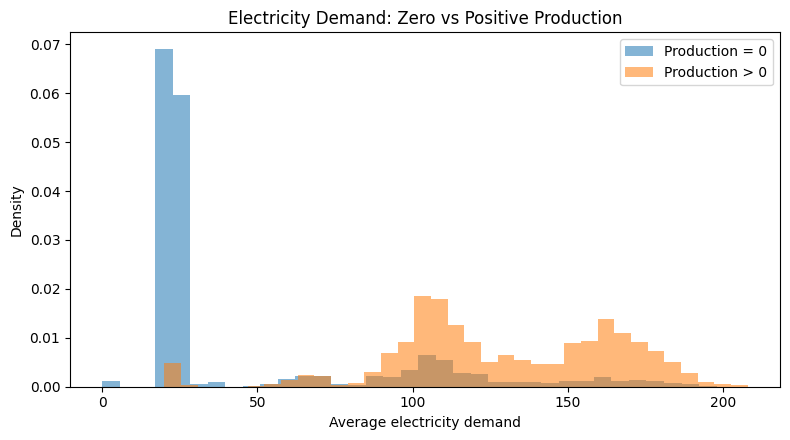

In [9]:
# 8. EDA Plot 4: 생산 0 vs 생산 > 0
zero_vals = df.loc[df['생산량'].eq(0), '평균']
prod_vals = df.loc[df['생산량'].gt(0), '평균']
plt.figure(figsize=(8, 4.5))
plt.hist(zero_vals, bins=35, alpha=0.55, density=True, label='Production = 0')
plt.hist(prod_vals, bins=35, alpha=0.55, density=True, label='Production > 0')
plt.title('Electricity Demand: Zero vs Positive Production')
plt.xlabel('Average electricity demand')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR/'04_zero_vs_positive_production.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Leakage-safe Feature Engineering

예측 시점의 정의는 다음과 같습니다.

- 목표: **시간대 `t`의 평균 전력수요**
- 사용 가능: `t` 이전까지의 전력 이력, `t`의 계획 생산량, 달력/요금/근무계획 등 사전에 알 수 있는 정보
- 사용 금지: `t` 시간대 내부의 `15분`, `30분`, `45분`, `60분` 실제 전력측정값

따라서 target과 같은 시간대의 전력 센서값을 직접 넣는 leakage를 차단합니다.

In [10]:
# 9. Feature engineering
model_df = df.copy()

# target
model_df['target_power'] = pd.to_numeric(model_df['평균'], errors='coerce')

# 과거 전력 이력: 모두 target 시간보다 이전 정보
for lag in [1, 2, 3, 6, 24, 48, 168]:
    model_df[f'power_lag_{lag}'] = model_df['평균'].shift(lag)

past_power = model_df['평균'].shift(1)
for win in [3, 6, 24]:
    model_df[f'power_roll_mean_{win}'] = past_power.rolling(win).mean()
for win in [6, 24]:
    model_df[f'power_roll_std_{win}'] = past_power.rolling(win).std()

# 달력 feature
hour = model_df['_hour']
dow = model_df['timestamp'].dt.dayofweek
month = model_df['timestamp'].dt.month
model_df['hour_sin'] = np.sin(2*np.pi*hour/24)
model_df['hour_cos'] = np.cos(2*np.pi*hour/24)
model_df['dow_sin'] = np.sin(2*np.pi*dow/7)
model_df['dow_cos'] = np.cos(2*np.pi*dow/7)
model_df['month_sin'] = np.sin(2*np.pi*(month-1)/12)
model_df['month_cos'] = np.cos(2*np.pi*(month-1)/12)
model_df['is_weekend'] = (dow >= 5).astype(int)

# 환경정보는 현재 실제값 대신 1시간 전 값 사용: forecast-time leakage 방지
for c in ['기온', '풍속', '습도', '강수량']:
    if c in model_df.columns:
        model_df[f'{c}_lag1'] = pd.to_numeric(model_df[c], errors='coerce').shift(1)

# 목표 시간대에 사전에 알 수 있다고 가정하는 계획/운영 변수
feature_cols = [
    '생산량',
    '전기요금(계절)', '공장인원', '인건비',
    'power_lag_1', 'power_lag_2', 'power_lag_3', 'power_lag_6',
    'power_lag_24', 'power_lag_48', 'power_lag_168',
    'power_roll_mean_3', 'power_roll_mean_6', 'power_roll_mean_24',
    'power_roll_std_6', 'power_roll_std_24',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend'
]
feature_cols += [f'{c}_lag1' for c in ['기온','풍속','습도','강수량'] if f'{c}_lag1' in model_df.columns]
feature_cols = [c for c in feature_cols if c in model_df.columns]

# 충분한 lag 확보를 위해 power_lag_168이 있는 행만 사용
model_df = model_df.loc[model_df['power_lag_168'].notna()].copy().reset_index(drop=True)

X = model_df[feature_cols].copy()
y = model_df['target_power'].copy()
timestamps = model_df['timestamp'].copy()

print('Modeling rows:', len(model_df))
print('Features:', len(feature_cols))
print(feature_cols)

# 안전검사: 같은 시간대 15/30/45/60분이 feature에 들어가지 않았는지 확인
for leak_col in ['15분','30분','45분','60분','평균','target_power']:
    assert leak_col not in feature_cols, f'Leakage 위험 feature 발견: {leak_col}'
print('Leakage feature check: PASS')

Modeling rows: 6000
Features: 27
['생산량', '전기요금(계절)', '공장인원', '인건비', 'power_lag_1', 'power_lag_2', 'power_lag_3', 'power_lag_6', 'power_lag_24', 'power_lag_48', 'power_lag_168', 'power_roll_mean_3', 'power_roll_mean_6', 'power_roll_mean_24', 'power_roll_std_6', 'power_roll_std_24', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', '기온_lag1', '풍속_lag1', '습도_lag1', '강수량_lag1']
Leakage feature check: PASS


## 5. Chronological Split
시계열 데이터이므로 random split을 사용하지 않습니다. 앞 70%는 Train, 다음 15%는 Validation, 마지막 15%는 Test로 나눕니다.

In [11]:
# 10. Chronological split
n = len(model_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

ts_train = timestamps.iloc[:train_end]
ts_val = timestamps.iloc[train_end:val_end]
ts_test = timestamps.iloc[val_end:]

print('Train:', X_train.shape, ts_train.min(), '~', ts_train.max())
print('Val  :', X_val.shape, ts_val.min(), '~', ts_val.max())
print('Test :', X_test.shape, ts_test.min(), '~', ts_test.max())

# Peak threshold는 반드시 train에서만 정의
PEAK_Q = 0.95
peak_threshold = float(y_train.quantile(PEAK_Q))
print(f'Train-only {PEAK_Q:.0%} peak threshold = {peak_threshold:.3f}')

Train: (4200, 27) 2021-01-08 00:00:00 ~ 2021-07-01 23:00:00
Val  : (900, 27) 2021-07-02 00:00:00 ~ 2021-08-08 11:00:00
Test : (900, 27) 2021-08-08 12:00:00 ~ 2021-09-14 23:00:00
Train-only 95% peak threshold = 173.000


## 6. Baseline + ML Models
모델 복잡도 자체가 목적이 아니므로 단순한 기준선부터 비선형 모델까지 비교합니다.

In [12]:
# 11. 모델 정의
models = {
    'Ridge': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    'RandomForest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(
            n_estimators=180,
            min_samples_leaf=3,
            max_features=0.8,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    'HistGradientBoosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=42
        ))
    ])
}

def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

def peak_metrics(y_true, y_pred, threshold):
    actual = np.asarray(y_true) >= threshold
    pred = np.asarray(y_pred) >= threshold
    tp = int(np.sum(actual & pred))
    fp = int(np.sum(~actual & pred))
    fn = int(np.sum(actual & ~pred))
    tn = int(np.sum(~actual & ~pred))
    precision = tp/(tp+fp) if (tp+fp) else 0.0
    recall = tp/(tp+fn) if (tp+fn) else 0.0
    fpr = fp/(fp+tn) if (fp+tn) else 0.0
    return {'PeakPrecision': precision, 'PeakRecall': recall, 'FalseAlarmRate': fpr,
            'TP':tp,'FP':fp,'FN':fn,'TN':tn}

# Persistence baseline = 직전시간 전력을 다음시간 예측치로 사용
val_pred_persistence = X_val['power_lag_1'].to_numpy()
baseline_val = {'Model':'Persistence'}
baseline_val.update(regression_metrics(y_val, val_pred_persistence))
baseline_val.update(peak_metrics(y_val, val_pred_persistence, peak_threshold))

# 시간대+요일 historical mean baseline
train_hist = pd.DataFrame({
    'hour': model_df.loc[:train_end-1, 'timestamp'].dt.hour.to_numpy(),
    'dow': model_df.loc[:train_end-1, 'timestamp'].dt.dayofweek.to_numpy(),
    'y': y_train.to_numpy()
})
hist_map = train_hist.groupby(['hour','dow'])['y'].mean()
global_mean = float(y_train.mean())

def hist_predict(ts_series, mapping, fallback):
    vals=[]
    for t in ts_series:
        vals.append(mapping.get((t.hour, t.dayofweek), fallback))
    return np.array(vals)

val_pred_hist = hist_predict(ts_val, hist_map, global_mean)
hist_val = {'Model':'HistoricalHourWeekday'}
hist_val.update(regression_metrics(y_val, val_pred_hist))
hist_val.update(peak_metrics(y_val, val_pred_hist, peak_threshold))

val_rows = [baseline_val, hist_val]
fitted_train_models = {}

for name, model in models.items():
    print('Training', name)
    model.fit(X_train, y_train)
    fitted_train_models[name] = model
    pred = model.predict(X_val)
    row = {'Model':name}
    row.update(regression_metrics(y_val, pred))
    row.update(peak_metrics(y_val, pred, peak_threshold))
    val_rows.append(row)

val_results = pd.DataFrame(val_rows).sort_values('MAE').reset_index(drop=True)
display(val_results)
val_results.to_csv(OUTPUT_DIR/'validation_metrics.csv', index=False, encoding='utf-8-sig')

Training Ridge
Training RandomForest
Training HistGradientBoosting


,Model,MAE,RMSE,R2,PeakPrecision,PeakRecall,FalseAlarmRate,TP,FP,FN,TN
0,RandomForest,10.602398,16.966105,0.926498,0.833333,0.447154,0.014157,55,11,68,766
1,HistGradientBoosting,12.221731,19.778857,0.900106,0.812500,0.422764,0.015444,52,12,71,765
2,Persistence,13.167778,23.945238,0.853589,0.528455,0.528455,0.074646,65,58,58,719
3,Ridge,14.612904,20.444859,0.893266,0.716216,0.430894,0.027027,53,21,70,756
4,HistoricalHourWeekday,34.870578,46.234499,0.454156,0.000000,0.000000,0.000000,0,0,123,777


In [13]:
# 12. Validation MAE 기준 best ML model 선택
ml_val = val_results[val_results['Model'].isin(models.keys())].copy()
best_model_name = ml_val.iloc[0]['Model']
print('Best ML model by Validation MAE:', best_model_name)

# 최종 모델은 Train + Validation으로 재학습
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

best_model = clone(models[best_model_name])
best_model.fit(X_trainval, y_trainval)
test_pred = best_model.predict(X_test)

final_metrics = {'Model': best_model_name}
final_metrics.update(regression_metrics(y_test, test_pred))
final_metrics.update(peak_metrics(y_test, test_pred, peak_threshold))

print('Final Test Metrics')
display(pd.DataFrame([final_metrics]))
pd.DataFrame([final_metrics]).to_csv(OUTPUT_DIR/'final_test_metrics.csv', index=False, encoding='utf-8-sig')

joblib.dump(best_model, OUTPUT_DIR/'best_model.joblib')

Best ML model by Validation MAE: RandomForest
Final Test Metrics


,Model,MAE,RMSE,R2,PeakPrecision,PeakRecall,FalseAlarmRate,TP,FP,FN,TN
0,RandomForest,6.166509,10.297049,0.96836,0.777778,0.5,0.020305,56,16,56,772


['/content/kamp05_outputs/best_model.joblib']

## 7. Test Prediction & Peak Detection

In [14]:
# 13. Test prediction table
pred_df = model_df.iloc[val_end:].copy().reset_index(drop=True)
pred_df['prediction'] = test_pred
pred_df['residual'] = pred_df['target_power'] - pred_df['prediction']
pred_df['abs_error'] = pred_df['residual'].abs()
pred_df['actual_peak'] = pred_df['target_power'] >= peak_threshold
pred_df['predicted_peak'] = pred_df['prediction'] >= peak_threshold

pred_df[['timestamp','target_power','prediction','residual','abs_error','생산량','actual_peak','predicted_peak']].to_csv(
    OUTPUT_DIR/'test_predictions.csv', index=False, encoding='utf-8-sig')

display(pred_df[['timestamp','target_power','prediction','residual','abs_error','생산량','actual_peak','predicted_peak']].head())

,timestamp,target_power,prediction,residual,abs_error,생산량,actual_peak,predicted_peak
0,2021-08-08 12:00:00,21,21.291779,-0.291779,0.291779,0,False,False
1,2021-08-08 13:00:00,21,22.806566,-1.806566,1.806566,0,False,False
2,2021-08-08 14:00:00,22,23.135545,-1.135545,1.135545,0,False,False
3,2021-08-08 15:00:00,21,22.597192,-1.597192,1.597192,0,False,False
4,2021-08-08 16:00:00,21,22.100804,-1.100804,1.100804,0,False,False


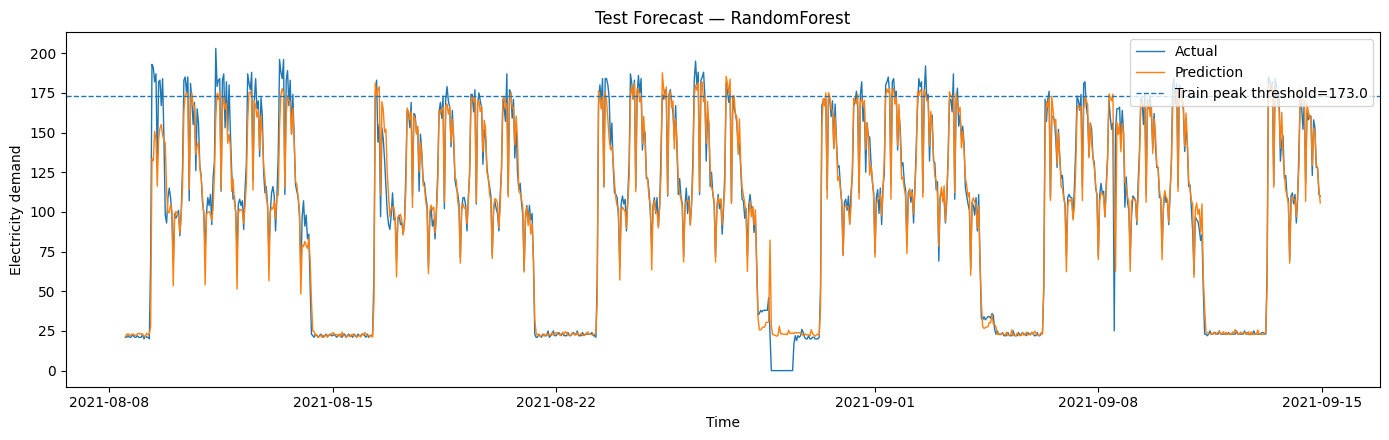

In [15]:
# 14. Actual vs Prediction plot
plt.figure(figsize=(14, 4.5))
plt.plot(pred_df['timestamp'], pred_df['target_power'], label='Actual', linewidth=1.0)
plt.plot(pred_df['timestamp'], pred_df['prediction'], label='Prediction', linewidth=1.0)
plt.axhline(peak_threshold, linestyle='--', linewidth=1.0, label=f'Train peak threshold={peak_threshold:.1f}')
plt.title(f'Test Forecast — {best_model_name}')
plt.xlabel('Time')
plt.ylabel('Electricity demand')
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR/'05_test_actual_vs_prediction.png', dpi=160, bbox_inches='tight')
plt.show()

In [16]:
# 15. Peak confusion summary
actual = pred_df['actual_peak'].to_numpy()
pred = pred_df['predicted_peak'].to_numpy()
tp = np.sum(actual & pred)
fp = np.sum(~actual & pred)
fn = np.sum(actual & ~pred)
tn = np.sum(~actual & ~pred)
cm = pd.DataFrame([[tn, fp],[fn, tp]], index=['Actual Non-peak','Actual Peak'], columns=['Pred Non-peak','Pred Peak'])
display(cm)

,Pred Non-peak,Pred Peak
Actual Non-peak,772,16
Actual Peak,56,56


## 8. Forecast Failure Analysis
“전력이 높은 조건”과 “모델이 틀리는 조건”을 구분해서 봅니다.

In [17]:
# 16. Subgroup error analysis
analysis_df = pred_df.copy()
analysis_df['hour'] = analysis_df['timestamp'].dt.hour
analysis_df['dow'] = analysis_df['timestamp'].dt.dayofweek
analysis_df['is_weekend_label'] = np.where(analysis_df['dow']>=5, 'Weekend', 'Weekday')
analysis_df['month'] = analysis_df['timestamp'].dt.month
analysis_df['peak_group'] = np.where(analysis_df['actual_peak'], 'Peak', 'Non-peak')
analysis_df['production_group'] = pd.cut(
    analysis_df['생산량'],
    bins=[-np.inf, 0, analysis_df.loc[analysis_df['생산량']>0,'생산량'].median(), np.inf],
    labels=['Zero','Low-positive','High-positive']
)

subgroup_tables = []
for col in ['peak_group','production_group','is_weekend_label','month','hour']:
    tmp = analysis_df.groupby(col, observed=False).agg(
        n=('abs_error','size'),
        MAE=('abs_error','mean'),
        MeanResidual=('residual','mean'),
        ActualDemand=('target_power','mean')
    ).reset_index()
    tmp.insert(0, 'group_variable', col)
    tmp = tmp.rename(columns={col:'group_value'})
    subgroup_tables.append(tmp)

subgroup_errors = pd.concat(subgroup_tables, ignore_index=True)
display(subgroup_errors.head(20))
subgroup_errors.to_csv(OUTPUT_DIR/'subgroup_error_analysis.csv', index=False, encoding='utf-8-sig')

,group_variable,group_value,n,MAE,MeanResidual,ActualDemand
0,peak_group,Non-peak,788,5.415519,-0.376961,89.640863
1,peak_group,Peak,112,11.450255,10.329403,181.080357
2,production_group,Zero,283,4.270777,-1.661345,28.445230
3,production_group,Low-positive,309,5.697367,1.353420,110.744337
4,production_group,High-positive,308,8.379032,2.960396,157.948052
5,is_weekend_label,Weekday,648,6.843995,1.947788,127.652778
6,is_weekend_label,Weekend,252,4.424401,-1.596503,32.535714
7,month,8,564,6.903078,1.287288,100.260638
8,month,9,336,4.930124,0.398267,102.294643
9,hour,0,37,6.903565,3.705940,55.675676


In [18]:
# 17. 가장 큰 under-prediction / over-prediction 확인
print('Largest under-predictions (actual >> prediction)')
display(analysis_df.nlargest(10, 'residual')[['timestamp','target_power','prediction','residual','생산량','_hour']])

print('Largest over-predictions (prediction >> actual)')
display(analysis_df.nsmallest(10, 'residual')[['timestamp','target_power','prediction','residual','생산량','_hour']])

Largest under-predictions (actual >> prediction)


,timestamp,target_power,prediction,residual,생산량,_hour
745,2021-09-08 13:00:00,152,62.556783,89.443217,1160,13
20,2021-08-09 08:00:00,193,133.581684,59.418316,749,8
21,2021-08-09 09:00:00,191,132.160722,58.839278,773,9
68,2021-08-11 08:00:00,203,159.315835,43.684165,783,8
116,2021-08-13 08:00:00,196,153.570122,42.429878,1107,8
19,2021-08-09 07:00:00,70,27.665630,42.334370,10,7
23,2021-08-09 11:00:00,187,145.761520,41.238480,1431,11
25,2021-08-09 13:00:00,182,145.950335,36.049665,7569,13
28,2021-08-09 16:00:00,184,148.478651,35.521349,1416,16
22,2021-08-09 10:00:00,182,150.761418,31.238582,408,10


Largest over-predictions (prediction >> actual)


,timestamp,target_power,prediction,residual,생산량,_hour
744,2021-09-08 12:00:00,25,102.548213,-77.548213,3,12
485,2021-08-28 17:00:00,22,82.253131,-60.253131,0,17
30,2021-08-09 18:00:00,98,143.415536,-45.415536,0,18
196,2021-08-16 16:00:00,116,152.134388,-36.134388,1490,16
190,2021-08-16 10:00:00,144,177.189762,-33.189762,1720,10
486,2021-08-28 18:00:00,0,28.153432,-28.153432,0,18
492,2021-08-29 00:00:00,0,27.946201,-27.946201,0,0
499,2021-08-29 07:00:00,0,25.411323,-25.411323,0,7
197,2021-08-16 17:00:00,100,124.535185,-24.535185,0,17
191,2021-08-16 11:00:00,155,178.823191,-23.823191,1472,11


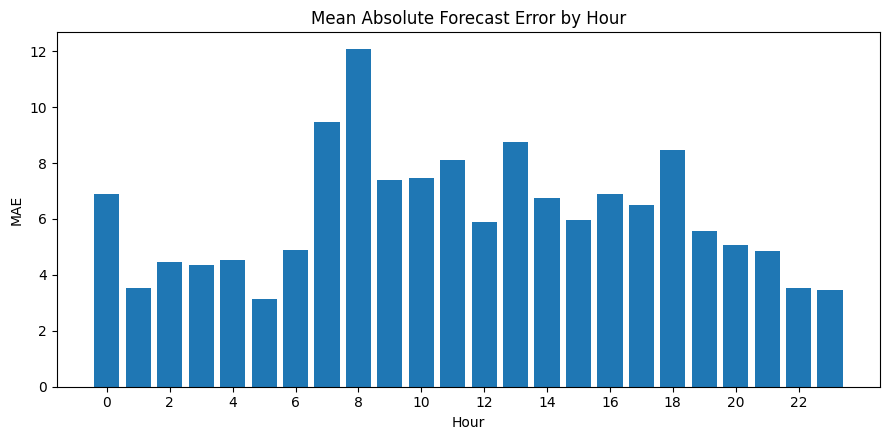

In [19]:
# 18. Residual by hour plot
hour_err = analysis_df.groupby('hour')['abs_error'].mean()
plt.figure(figsize=(9, 4.5))
plt.bar(hour_err.index, hour_err.values)
plt.title('Mean Absolute Forecast Error by Hour')
plt.xlabel('Hour')
plt.ylabel('MAE')
plt.xticks(range(0,24,2))
plt.tight_layout()
plt.savefig(PLOT_DIR/'06_error_by_hour.png', dpi=160, bbox_inches='tight')
plt.show()

## 9. Feature Importance
Permutation importance를 사용하므로 Ridge/RandomForest/Gradient Boosting 중 어떤 모델이 선택되어도 동일한 방식으로 비교할 수 있습니다.

,feature,importance_mean,importance_std
4,power_lag_1,33.520179,1.054358
11,power_roll_mean_3,6.444933,0.283485
17,hour_cos,6.071850,0.252030
10,power_lag_168,3.792238,0.168177
6,power_lag_3,3.032641,0.213431
9,power_lag_48,1.164129,0.140999
8,power_lag_24,0.949419,0.091240
0,생산량,0.866669,0.033699
14,power_roll_std_6,0.700244,0.171513
16,hour_sin,0.673293,0.101789


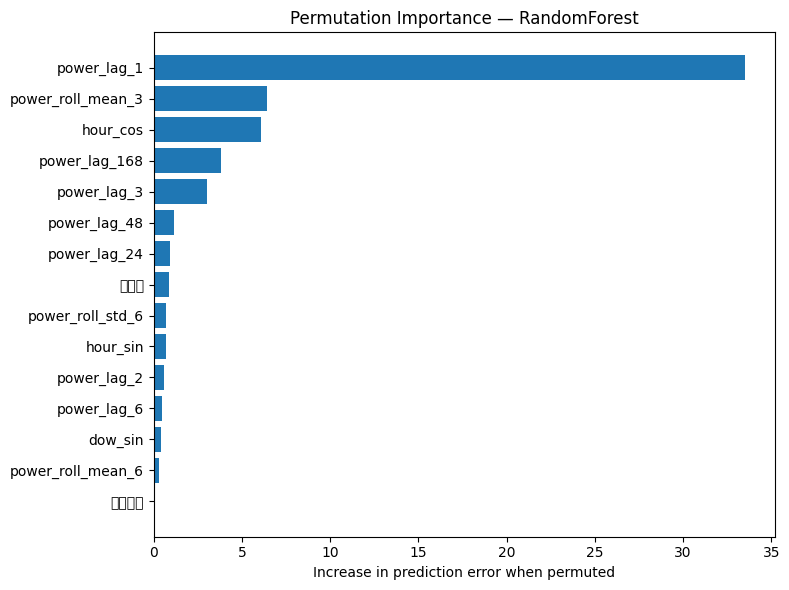

In [20]:
# 19. Permutation importance
# 실행시간을 줄이면서 안정적으로 비교하기 위해 test에서 최대 500개를 균등 간격으로 샘플링
imp_n = min(500, len(X_test))
imp_idx = np.linspace(0, len(X_test)-1, imp_n, dtype=int)
X_imp = X_test.iloc[imp_idx]
y_imp = y_test.iloc[imp_idx]
perm = permutation_importance(
    best_model, X_imp, y_imp,
    scoring='neg_mean_absolute_error',
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

display(importance_df.head(20))
importance_df.to_csv(OUTPUT_DIR/'feature_importance.csv', index=False, encoding='utf-8-sig')

plot_imp = importance_df.head(15).sort_values('importance_mean')
plt.figure(figsize=(8, 6))
plt.barh(plot_imp['feature'], plot_imp['importance_mean'])
plt.title(f'Permutation Importance — {best_model_name}')
plt.xlabel('Increase in prediction error when permuted')
plt.tight_layout()
plt.savefig(PLOT_DIR/'07_feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()

## 10. Peak-Risk Conditions
Peak 발생 시점의 생산량, 시간대, 요일 등을 비피크와 비교합니다. 이는 **연관성 분석**이며 인과효과로 해석하지 않습니다.

In [21]:
# 20. Peak condition summary
peak_condition_summary = analysis_df.groupby('actual_peak').agg(
    n=('target_power','size'),
    avg_power=('target_power','mean'),
    avg_production=('생산량','mean'),
    median_production=('생산량','median'),
    avg_hour=('hour','mean')
).reset_index()
display(peak_condition_summary)
peak_condition_summary.to_csv(OUTPUT_DIR/'peak_condition_summary.csv', index=False, encoding='utf-8-sig')

peak_by_hour = analysis_df.groupby('hour')['actual_peak'].agg(['mean','sum','count']).reset_index()
peak_by_hour['peak_rate'] = peak_by_hour['mean']

display(peak_by_hour[['hour','peak_rate','sum','count']].sort_values('peak_rate', ascending=False).head(10))
peak_by_hour.to_csv(OUTPUT_DIR/'peak_rate_by_hour.csv', index=False, encoding='utf-8-sig')

,actual_peak,n,avg_power,avg_production,median_production,avg_hour
0,False,788,89.640863,468.236041,94.5,11.572335
1,True,112,181.080357,1392.848214,1198.5,11.633929


,hour,peak_rate,sum,count
11,11,0.567568,21,37
14,14,0.473684,18,38
8,8,0.432432,16,37
13,13,0.421053,16,38
9,9,0.405405,15,37
10,10,0.297297,11,37
16,16,0.210526,8,38
15,15,0.131579,5,38
18,18,0.052632,2,38
6,6,0.000000,0,37


## 11. Production-shifting What-if Scenario

가장 높은 예측 peak를 가진 **test 기간의 상위 10개 날짜**를 대상으로, 해당 날짜의 predicted peak 시간대 생산량 **10%**를 ±3시간 범위의 예측부하가 가장 낮은 시간대로 옮깁니다.

- 총 일일 생산량 보존
- 모델의 `생산량` feature만 변경
- 실제 공정제약/설비제약을 모두 반영한 최적화가 아니라 **1차 model-based what-if**
- 결과는 인과적 절감효과가 아니라 모델이 예측하는 변화입니다.

In [22]:
# 21. What-if scenario
SHIFT_FRAC = 0.10
NEIGHBOR_HOURS = 3
TOP_DAYS = 10

# X_test와 timestamp의 index를 재정렬해서 scenario용 dataframe 생성
X_test_scenario = X_test.reset_index(drop=True).copy()
scenario_base = pd.DataFrame({
    'timestamp': ts_test.reset_index(drop=True),
    'actual': y_test.reset_index(drop=True),
    'baseline_pred': test_pred,
})
scenario_base['date'] = scenario_base['timestamp'].dt.date
scenario_base['hour'] = scenario_base['timestamp'].dt.hour
scenario_base['production'] = X_test_scenario['생산량'].to_numpy()

# 예측 일최대가 높은 날짜 선택
daily_peak = scenario_base.groupby('date')['baseline_pred'].max().sort_values(ascending=False)
target_days = list(daily_peak.head(TOP_DAYS).index)

scenario_rows=[]
for day in target_days:
    idx = scenario_base.index[scenario_base['date'] == day].tolist()
    if len(idx) < 2:
        continue
    day_base = scenario_base.loc[idx].copy()
    # 생산량 > 0인 행 중 baseline predicted demand가 가장 큰 시간
    source_candidates = day_base[day_base['production'] > 0]
    if source_candidates.empty:
        continue
    src_idx = source_candidates['baseline_pred'].idxmax()
    src_hour = int(scenario_base.loc[src_idx, 'hour'])
    src_prod = float(X_test_scenario.loc[src_idx, '생산량'])
    shift_amount = src_prod * SHIFT_FRAC
    if shift_amount <= 0:
        continue

    # 같은 날 ±3시간 후보 중 baseline predicted load가 가장 낮은 시간
    cand = day_base[(day_base.index != src_idx) & (day_base['hour'].sub(src_hour).abs() <= NEIGHBOR_HOURS)]
    if cand.empty:
        continue
    dst_idx = cand['baseline_pred'].idxmin()
    dst_hour = int(scenario_base.loc[dst_idx, 'hour'])

    # 날짜 전체 X 복사 후 생산량만 변경
    X_day = X_test_scenario.loc[idx].copy()
    src_local = idx.index(src_idx)
    dst_local = idx.index(dst_idx)
    X_day.iloc[src_local, X_day.columns.get_loc('생산량')] -= shift_amount
    X_day.iloc[dst_local, X_day.columns.get_loc('생산량')] += shift_amount

    scenario_pred = best_model.predict(X_day)
    base_pred = scenario_base.loc[idx, 'baseline_pred'].to_numpy()
    before_peak = float(np.max(base_pred))
    after_peak = float(np.max(scenario_pred))

    scenario_rows.append({
        'date': str(day),
        'source_hour': src_hour,
        'destination_hour': dst_hour,
        'shift_amount': shift_amount,
        'baseline_predicted_peak': before_peak,
        'scenario_predicted_peak': after_peak,
        'predicted_peak_reduction': before_peak - after_peak,
        'predicted_peak_reduction_pct': 100*(before_peak-after_peak)/before_peak if before_peak else np.nan,
        'daily_production_before': float(X_test_scenario.loc[idx, '생산량'].sum()),
        'daily_production_after': float(X_day['생산량'].sum()),
    })

scenario_results = pd.DataFrame(scenario_rows)
if len(scenario_results):
    display(scenario_results)
    print('Mean predicted peak reduction:', scenario_results['predicted_peak_reduction'].mean())
    print('Mean predicted peak reduction %:', scenario_results['predicted_peak_reduction_pct'].mean())
    print('Days with predicted improvement:', int((scenario_results['predicted_peak_reduction'] > 0).sum()), '/', len(scenario_results))
else:
    print('조건을 만족하는 what-if 날짜가 없습니다.')

scenario_results.to_csv(OUTPUT_DIR/'what_if_scheduling_results.csv', index=False, encoding='utf-8-sig')

,date,source_hour,destination_hour,shift_amount,baseline_predicted_peak,scenario_predicted_peak,predicted_peak_reduction,predicted_peak_reduction_pct,daily_production_before,daily_production_after
0,2021-08-25,8,5,47.0,187.677544,187.677544,0.000000e+00,0.000000e+00,22076.0,22076.0
1,2021-08-27,8,5,26.3,185.446525,184.111672,1.334853e+00,7.198051e-01,25769.0,25769.0
2,2021-08-26,14,12,74.6,181.885883,181.818476,6.740741e-02,3.706027e-02,20064.0,20064.0
3,2021-08-16,8,6,56.6,181.222478,181.390468,-1.679894e-01,-9.269789e-02,10238.0,10238.0
4,2021-08-24,11,12,90.1,181.118664,181.066098,5.256614e-02,2.902304e-02,16955.0,16955.0
5,2021-09-13,11,12,94.6,180.629054,180.695522,-6.646825e-02,-3.679821e-02,14174.0,14174.0
6,2021-09-14,8,5,43.2,178.043909,177.987560,5.634921e-02,3.164905e-02,19318.0,19318.0
7,2021-09-01,11,12,167.7,177.950709,177.941311,9.398148e-03,5.281321e-03,19638.0,19638.0
8,2021-08-13,10,7,102.3,177.745922,177.711199,3.472222e-02,1.953475e-02,17668.0,17668.0
9,2021-09-02,13,12,137.9,177.095404,177.095404,-2.842171e-14,-1.604881e-14,19351.0,19351.0


Mean predicted peak reduction: 0.13208389295888595
Mean predicted peak reduction %: 0.07128573976237322
Days with predicted improvement: 6 / 10


## 12. 자동 요약 및 결과 ZIP 다운로드
결과물에는 EDA 그림, metrics, test prediction, error analysis, feature importance, what-if 결과와 최종 모델이 포함됩니다.

In [23]:
# 22. 분석 요약 텍스트 생성
summary_lines = []
summary_lines.append('KAMP 05 Resource Optimization Analysis Summary')
summary_lines.append('='*55)
summary_lines.append(f'Raw data shape: {df_raw.shape}')
summary_lines.append(f'Analysis period: {df["timestamp"].min()} ~ {df["timestamp"].max()}')
summary_lines.append(f'Production-power correlation: {corr_prod_power:.4f}')
summary_lines.append(f'Train-only 95th percentile peak threshold: {peak_threshold:.4f}')
summary_lines.append(f'Best ML model by validation MAE: {best_model_name}')
for k,v in final_metrics.items():
    if k != 'Model':
        summary_lines.append(f'Test {k}: {v}')
if len(scenario_results):
    summary_lines.append(f'What-if mean predicted peak reduction: {scenario_results["predicted_peak_reduction"].mean():.4f}')
    summary_lines.append(f'What-if mean predicted peak reduction (%): {scenario_results["predicted_peak_reduction_pct"].mean():.4f}')

summary_text = '\n'.join(summary_lines)
print(summary_text)
with open(OUTPUT_DIR/'analysis_summary.txt','w',encoding='utf-8') as f:
    f.write(summary_text)

KAMP 05 Resource Optimization Analysis Summary
Raw data shape: (6168, 18)
Analysis period: 2021-01-01 00:00:00 ~ 2021-09-14 23:00:00
Production-power correlation: 0.5179
Train-only 95th percentile peak threshold: 173.0000
Best ML model by validation MAE: RandomForest
Test MAE: 6.16650876260984
Test RMSE: 10.297048814072463
Test R2: 0.9683601885127472
Test PeakPrecision: 0.7777777777777778
Test PeakRecall: 0.5
Test FalseAlarmRate: 0.02030456852791878
Test TP: 56
Test FP: 16
Test FN: 56
Test TN: 772
What-if mean predicted peak reduction: 0.1321
What-if mean predicted peak reduction (%): 0.0713


In [24]:
# 23. 최종 결과 ZIP 생성 + Colab 다운로드
archive_base = str(OUTPUT_DIR.parent / 'KAMP05_analysis_results')
zip_result = shutil.make_archive(archive_base, 'zip', root_dir=OUTPUT_DIR)
print('Result ZIP:', zip_result)

if IN_COLAB:
    from google.colab import files
    files.download(zip_result)
else:
    print('로컬 실행이므로 자동 다운로드는 생략합니다.')

Result ZIP: /content/KAMP05_analysis_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 해석 시 주의사항
1. `production quantity`와 전력의 관계는 관찰자료의 **연관성**이며 자동으로 인과관계를 의미하지 않습니다.
2. What-if 결과는 실제 설비제약을 모두 반영한 최적화가 아니라 **모델 기반 1차 시나리오**입니다.
3. Proposal/Final에서 성능을 보고할 때는 반드시 이 노트북을 직접 실행해 나온 실제 숫자를 사용하세요.
4. CSE304 최종발표의 LLM Usage appendix에는 코드 작성/디버깅에 LLM을 사용한 사실과 검증 방법을 기재해야 합니다.